In [1]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected+png'
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

data = pd.read_csv("Competition_Data.csv")

print(data.head())

   Index Fiscal_Week_ID   Store_ID   Item_ID   Price  Item_Quantity  \
0      0        2019-11  store_459  item_526  134.49            435   
1      1        2019-11  store_459  item_526  134.49            435   
2      2        2019-11  store_459  item_526  134.49            435   
3      3        2019-11  store_459  item_526  134.49            435   
4      4        2019-11  store_459  item_526  134.49            435   

   Sales_Amount_No_Discount  Sales_Amount  Competition_Price  
0                   4716.74      11272.59             206.44  
1                   4716.74      11272.59             158.01  
2                   4716.74      11272.59             278.03  
3                   4716.74      11272.59             222.66  
4                   4716.74      11272.59             195.32  


In [2]:
# calculate the percentage change in price and quantity
data['Price_Change'] = data.groupby(['Store_ID', 'Item_ID'])['Price'].pct_change()
data['Quantity_Change'] = data.groupby(['Store_ID', 'Item_ID'])['Item_Quantity'].pct_change()

# calculate the price elasticity of demand
data['PED'] = data['Quantity_Change'] / data['Price_Change']

data.replace([float('inf'), -float('inf')], float('nan'), inplace=True)
data.dropna(subset=['PED'], inplace=True)

# summary statistics for PED
ped_summary = data['PED'].describe()

ped_summary

count    8234.000000
mean       -0.461013
std        35.573810
min     -1455.268409
25%        -0.796818
50%         0.000000
75%         0.765515
max      1127.613636
Name: PED, dtype: float64

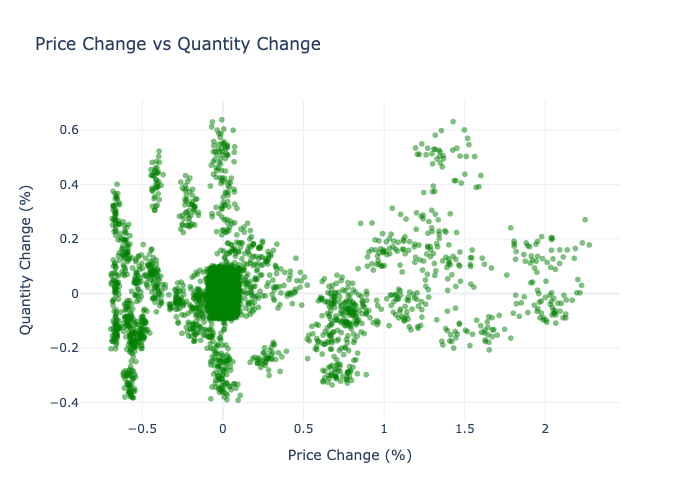

In [3]:
fig_scatter = px.scatter(data, x='Price_Change', y='Quantity_Change', title='Price Change vs Quantity Change',
                         labels={'Price_Change': 'Price Change (%)', 'Quantity_Change': 'Quantity Change (%)'})
fig_scatter.update_traces(marker=dict(color='green', opacity=0.5))
fig_scatter.update_layout(xaxis_title='Price Change (%)', yaxis_title='Quantity Change (%)',
                          template='plotly_white')
fig_scatter.show()

In [4]:
# define PED thresholds for segmentation
elastic_threshold = 1
inelastic_threshold = -1

# segment the data based on PED
data['Segment'] = 'Unitary Elastic'
data.loc[data['PED'] > elastic_threshold, 'Segment'] = 'Highly Elastic'
data.loc[data['PED'] < inelastic_threshold, 'Segment'] = 'Inelastic'
data.loc[data['PED'] == 0, 'Segment'] = 'Zero Elasticity'
data.loc[data['PED'] < 0, 'Segment'] = 'Negative Elasticity'

# count the number of items in each segment
segment_counts = data['Segment'].value_counts()

segment_counts

Segment
Negative Elasticity    4031
Unitary Elastic        2300
Highly Elastic         1740
Zero Elasticity         163
Name: count, dtype: int64

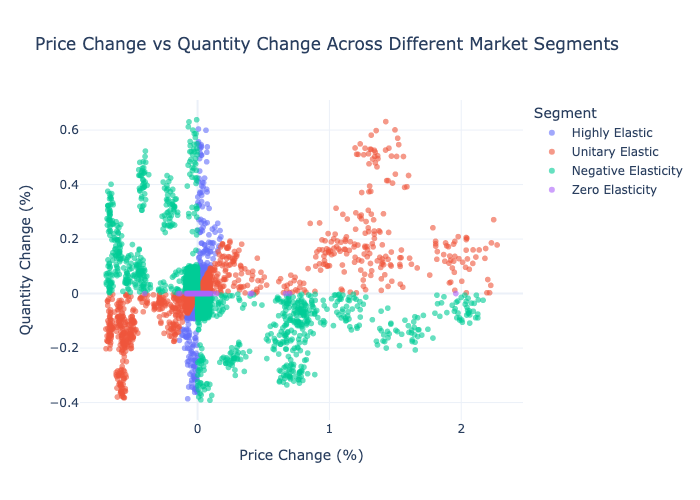

In [5]:
fig_segment = px.scatter(data, x='Price_Change', y='Quantity_Change', color='Segment',
                         title='Price Change vs Quantity Change Across Different Market Segments',
                         labels={'Price_Change': 'Price Change (%)', 'Quantity_Change': 'Quantity Change (%)'},
                         color_continuous_scale='Viridis', opacity=0.6)

fig_segment.update_layout(xaxis_title='Price Change (%)', yaxis_title='Quantity Change (%)',
                          template='plotly_white')

fig_segment.show()